# Stage 7 — Error Analysis

Stage 7 phân tích lỗi dựa trên prediction outputs từ Stage 6.

Không train lại model, không evaluate lại model. Notebook này chỉ đọc prediction files và sinh bảng phân tích lỗi.


## 1. Imports and project paths

In [2]:
from pathlib import Path
from datetime import datetime
import sys

import pandas as pd
import matplotlib.pyplot as plt
import yaml

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_PATH = PROJECT_ROOT / "configs" / "07_error_analysis_config.yaml"

from src.error_analysis import (
    load_noisy_files,
    build_text_lookup,
    load_predictions,
    add_tokenization_features,
    summarize_error_rates,
    summarize_confusion_pairs,
    sample_error_rows,
    minority_class_errors,
    no_accent_errors,
    tokenization_error_summary,
    select_report_columns,
)

print("Project root:", PROJECT_ROOT)
print("Config path:", CONFIG_PATH)


Project root: d:\project-ml-engineering\nlp-phobert-student-feedback
Config path: d:\project-ml-engineering\nlp-phobert-student-feedback\configs\07_error_analysis_config.yaml


## 2. Load config and input files

In [3]:
if not CONFIG_PATH.exists():
    raise FileNotFoundError(f"Missing config: {CONFIG_PATH}")

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

source_cfg = config["source"]
output_cfg = config["output"]
analysis_cfg = config["analysis"]
filter_cfg = config.get("model_filter", {})

CLEAN_TEST_PATH = PROJECT_ROOT / source_cfg["clean_test_path"]
NOISY_DIR = PROJECT_ROOT / source_cfg["noisy_dir"]
NOISY_PATTERN = source_cfg.get("noisy_file_pattern", "04_test_*.csv")
BASELINE_PREDICTIONS_PATH = PROJECT_ROOT / source_cfg["baseline_predictions_path"]
PHOBERT_PREDICTIONS_LIGHT_PATH = PROJECT_ROOT / source_cfg["phobert_predictions_light_path"]
TOKENIZATION_ANALYSIS_PATH = PROJECT_ROOT / source_cfg["tokenization_analysis_path"]

TABLES_DIR = PROJECT_ROOT / output_cfg["reports_tables_dir"]
FIGURES_DIR = PROJECT_ROOT / output_cfg["reports_figures_dir"]
NOTES_DIR = PROJECT_ROOT / output_cfg["reports_notes_dir"]

for path in [TABLES_DIR, FIGURES_DIR, NOTES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

required_paths = [
    CLEAN_TEST_PATH,
    BASELINE_PREDICTIONS_PATH,
    PHOBERT_PREDICTIONS_LIGHT_PATH,
]
for path in required_paths:
    if not path.exists():
        raise FileNotFoundError(f"Missing required input: {path}")

clean_test_df = pd.read_csv(CLEAN_TEST_PATH)
noisy_frames = load_noisy_files(NOISY_DIR, NOISY_PATTERN)

print("Clean test:", clean_test_df.shape)
print("Noisy sets:")
for noise_type, df in noisy_frames.items():
    print(f"- {noise_type}: {df.shape}")
print("Baseline predictions:", BASELINE_PREDICTIONS_PATH)
print("PhoBERT predictions:", PHOBERT_PREDICTIONS_LIGHT_PATH)
print("Tokenization analysis:", TOKENIZATION_ANALYSIS_PATH)


Clean test: (3166, 9)
Noisy sets:
- domain_abbreviation: (3166, 15)
- elongation: (3166, 15)
- mixed_noise: (3166, 15)
- no_accent: (3166, 15)
- teencode_colloquial: (3166, 15)
- typo: (3166, 15)
Baseline predictions: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\06_model_predictions_all.csv
PhoBERT predictions: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\06b_phobert_predictions_light.csv
Tokenization analysis: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\05_segmentation_tokenization_analysis.csv


## 3. Consolidate predictions with text and tokenization metrics

In [4]:
text_lookup_df = build_text_lookup(clean_test_df, noisy_frames)

predictions_df = load_predictions(
    baseline_predictions_path=BASELINE_PREDICTIONS_PATH,
    phobert_predictions_light_path=PHOBERT_PREDICTIONS_LIGHT_PATH,
    text_lookup_df=text_lookup_df,
)

predictions_df = add_tokenization_features(
    predictions_df=predictions_df,
    tokenization_analysis_path=TOKENIZATION_ANALYSIS_PATH,
)

all_predictions_path = TABLES_DIR / "07_predictions_with_text_and_tokenization.csv"
predictions_df.to_csv(all_predictions_path, index=False, encoding="utf-8-sig")

print("Predictions shape:", predictions_df.shape)
print("Saved:", all_predictions_path)
display(predictions_df.head())


Predictions shape: (302144, 27)
Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\07_predictions_with_text_and_tokenization.csv


,id,noise_type,evaluation_scope,text,true_label,is_changed,changed_token_ratio,severity,original_text,noisy_text,...,is_changed_lookup,num_subwords_clean,num_subwords_noisy,subword_delta,subword_inflation_ratio,subword_change_flag,segmentation_change_flag,segment_delta,segmentation_jaccard_distance,subword_jaccard_distance
0,test_0,clean,full,nói tiếng anh lưu loát .,positive,True,0.0,clean,nói tiếng anh lưu loát .,nói tiếng anh lưu loát .,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,test_1,clean,full,giáo viên rất vui tính .,positive,True,0.0,clean,giáo viên rất vui tính .,giáo viên rất vui tính .,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,test_2,clean,full,cô max có tâm .,positive,True,0.0,clean,cô max có tâm .,cô max có tâm .,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,test_3,clean,full,"giảng bài thu hút , dí dỏm .",positive,True,0.0,clean,"giảng bài thu hút , dí dỏm .","giảng bài thu hút , dí dỏm .",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,test_4,clean,full,"giáo viên không giảng dạy kiến thức , hướng dẫ...",negative,True,0.0,clean,"giáo viên không giảng dạy kiến thức , hướng dẫ...","giáo viên không giảng dạy kiến thức , hướng dẫ...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Error-rate summary

In [5]:
error_summary = summarize_error_rates(predictions_df)

error_summary_path = TABLES_DIR / "07_error_summary_by_model_noise_task.csv"
error_summary.to_csv(error_summary_path, index=False, encoding="utf-8-sig")

display(error_summary.sort_values(["task", "model_name", "noise_type", "evaluation_scope"]).head(50))
print("Saved:", error_summary_path)


,task,model_type,model_name,noise_type,evaluation_scope,num_samples,num_errors,accuracy,mean_changed_token_ratio,error_rate
0,sentiment,baseline,majority_class,clean,full,3166,1576,0.502211,0.000000,0.497789
1,sentiment,baseline,majority_class,domain_abbreviation,changed_only,1530,817,0.466013,0.186705,0.533987
2,sentiment,baseline,majority_class,domain_abbreviation,full,3166,1576,0.502211,0.090227,0.497789
3,sentiment,baseline,majority_class,elongation,changed_only,3164,1575,0.502212,0.101928,0.497788
4,sentiment,baseline,majority_class,elongation,full,3166,1576,0.502211,0.101863,0.497789
5,sentiment,baseline,majority_class,mixed_noise,changed_only,3135,1560,0.502392,0.210932,0.497608
6,sentiment,baseline,majority_class,mixed_noise,full,3166,1576,0.502211,0.208866,0.497789
7,sentiment,baseline,majority_class,no_accent,changed_only,3162,1574,0.502214,0.759223,0.497786
8,sentiment,baseline,majority_class,no_accent,full,3166,1576,0.502211,0.758264,0.497789
9,sentiment,baseline,majority_class,teencode_colloquial,changed_only,1541,834,0.458793,0.099381,0.541207


Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\07_error_summary_by_model_noise_task.csv


## 5. Confusion pair summary

In [6]:
confusion_pairs = summarize_confusion_pairs(predictions_df)

confusion_pairs_path = TABLES_DIR / "07_confusion_pairs_summary.csv"
confusion_pairs.to_csv(confusion_pairs_path, index=False, encoding="utf-8-sig")

display(confusion_pairs.head(int(analysis_cfg.get("top_confusion_pairs", 30))))
print("Saved:", confusion_pairs_path)


,task,model_type,model_name,noise_type,evaluation_scope,true_label,pred_label,num_errors
0,sentiment,baseline,majority_class,clean,full,negative,positive,1409
1,sentiment,baseline,majority_class,clean,full,neutral,positive,167
4,sentiment,baseline,majority_class,domain_abbreviation,full,negative,positive,1409
2,sentiment,baseline,majority_class,domain_abbreviation,changed_only,negative,positive,761
5,sentiment,baseline,majority_class,domain_abbreviation,full,neutral,positive,167
3,sentiment,baseline,majority_class,domain_abbreviation,changed_only,neutral,positive,56
6,sentiment,baseline,majority_class,elongation,changed_only,negative,positive,1409
8,sentiment,baseline,majority_class,elongation,full,negative,positive,1409
9,sentiment,baseline,majority_class,elongation,full,neutral,positive,167
7,sentiment,baseline,majority_class,elongation,changed_only,neutral,positive,166


Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\07_confusion_pairs_summary.csv


## 6. Representative error samples

In [7]:
top_n = int(analysis_cfg.get("top_error_samples_per_group", 30))
exclude_majority = bool(filter_cfg.get("exclude_majority_from_samples", True))

error_samples = sample_error_rows(
    predictions_df=predictions_df,
    top_n_per_group=top_n,
    exclude_majority=exclude_majority,
)

error_samples_report = select_report_columns(error_samples)

error_samples_path = TABLES_DIR / "07_error_samples_all.csv"
error_samples_report.to_csv(error_samples_path, index=False, encoding="utf-8-sig")

for task in analysis_cfg.get("tasks", ["sentiment", "topic"]):
    task_df = error_samples_report[error_samples_report["task"] == task].copy()
    task_path = TABLES_DIR / f"07_error_samples_{task}.csv"
    task_df.to_csv(task_path, index=False, encoding="utf-8-sig")
    print("Saved:", task_path, task_df.shape)

display(error_samples_report.head(30))
print("Saved:", error_samples_path)


Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\07_error_samples_sentiment.csv (1170, 15)
Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\07_error_samples_topic.csv (1170, 15)


,task,model_type,model_name,noise_type,evaluation_scope,id,true_label,pred_label,severity,changed_token_ratio,subword_delta,subword_inflation_ratio,original_text,noisy_text,text
0,topic,baseline,tfidf_char_svm,no_accent,full,test_242,training_program,lecturer,high,0.785714,32.0,1.326531,"thực hành hình thức 2 tỏ ra kém hiệu quả , chủ...","thuc hanh hinh thuc 2 to ra kem hieu qua , chu...","thuc hanh hinh thuc 2 to ra kem hieu qua , chu..."
1,topic,baseline,tfidf_char_svm,no_accent,changed_only,test_242,training_program,lecturer,high,0.785714,32.0,1.326531,"thực hành hình thức 2 tỏ ra kém hiệu quả , chủ...","thuc hanh hinh thuc 2 to ra kem hieu qua , chu...","thuc hanh hinh thuc 2 to ra kem hieu qua , chu..."
2,topic,baseline,tfidf_word_svm,no_accent,full,test_242,training_program,lecturer,high,0.785714,32.0,1.326531,"thực hành hình thức 2 tỏ ra kém hiệu quả , chủ...","thuc hanh hinh thuc 2 to ra kem hieu qua , chu...","thuc hanh hinh thuc 2 to ra kem hieu qua , chu..."
3,topic,baseline,tfidf_word_svm,no_accent,changed_only,test_242,training_program,lecturer,high,0.785714,32.0,1.326531,"thực hành hình thức 2 tỏ ra kém hiệu quả , chủ...","thuc hanh hinh thuc 2 to ra kem hieu qua , chu...","thuc hanh hinh thuc 2 to ra kem hieu qua , chu..."
4,sentiment,phobert,phobert_base,no_accent,full,test_242,negative,neutral,high,0.785714,32.0,1.326531,"thực hành hình thức 2 tỏ ra kém hiệu quả , chủ...","thuc hanh hinh thuc 2 to ra kem hieu qua , chu...","thuc hanh hinh thuc 2 to ra kem hieu qua , chu..."
5,sentiment,phobert,phobert_base,no_accent,changed_only,test_242,negative,neutral,high,0.785714,32.0,1.326531,"thực hành hình thức 2 tỏ ra kém hiệu quả , chủ...","thuc hanh hinh thuc 2 to ra kem hieu qua , chu...","thuc hanh hinh thuc 2 to ra kem hieu qua , chu..."
6,topic,phobert,phobert_base,no_accent,full,test_242,training_program,lecturer,high,0.785714,32.0,1.326531,"thực hành hình thức 2 tỏ ra kém hiệu quả , chủ...","thuc hanh hinh thuc 2 to ra kem hieu qua , chu...","thuc hanh hinh thuc 2 to ra kem hieu qua , chu..."
7,topic,phobert,phobert_base,no_accent,changed_only,test_242,training_program,lecturer,high,0.785714,32.0,1.326531,"thực hành hình thức 2 tỏ ra kém hiệu quả , chủ...","thuc hanh hinh thuc 2 to ra kem hieu qua , chu...","thuc hanh hinh thuc 2 to ra kem hieu qua , chu..."
8,sentiment,baseline,tfidf_char_svm,no_accent,full,test_149,positive,negative,high,0.782609,21.0,1.456522,cách mà thầy hướng cho sinh viên tiếp cận kiến...,cach ma thay huong cho sinh vien tiep can kien...,cach ma thay huong cho sinh vien tiep can kien...
9,sentiment,baseline,tfidf_char_svm,no_accent,changed_only,test_149,positive,negative,high,0.782609,21.0,1.456522,cách mà thầy hướng cho sinh viên tiếp cận kiến...,cach ma thay huong cho sinh vien tiep can kien...,cach ma thay huong cho sinh vien tiep can kien...


Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\07_error_samples_all.csv


## 7. Minority and difficult class errors

In [8]:
minority_map = analysis_cfg.get("minority_or_difficult_classes", {})

minority_errors = minority_class_errors(
    predictions_df=predictions_df,
    class_map=minority_map,
    exclude_majority=exclude_majority,
)

minority_errors_report = select_report_columns(minority_errors)

minority_errors_path = TABLES_DIR / "07_minority_class_error_samples.csv"
minority_errors_report.to_csv(minority_errors_path, index=False, encoding="utf-8-sig")

if minority_errors.empty:
    minority_summary = pd.DataFrame()
else:
    minority_summary = (
        minority_errors
        .groupby(["task", "true_label", "model_type", "model_name", "noise_type", "evaluation_scope"])
        .size()
        .reset_index(name="num_errors")
        .sort_values(["task", "true_label", "num_errors"], ascending=[True, True, False])
    )

minority_summary_path = TABLES_DIR / "07_minority_class_error_summary.csv"
minority_summary.to_csv(minority_summary_path, index=False, encoding="utf-8-sig")

display(minority_summary.head(50))
display(minority_errors_report.head(30))

print("Saved:", minority_errors_path)
print("Saved:", minority_summary_path)


,task,true_label,model_type,model_name,noise_type,evaluation_scope,num_errors
23,sentiment,neutral,baseline,tfidf_word_svm,teencode_colloquial,full,119
13,sentiment,neutral,baseline,tfidf_word_svm,clean,full,118
25,sentiment,neutral,baseline,tfidf_word_svm,typo,full,117
16,sentiment,neutral,baseline,tfidf_word_svm,elongation,changed_only,116
17,sentiment,neutral,baseline,tfidf_word_svm,elongation,full,116
15,sentiment,neutral,baseline,tfidf_word_svm,domain_abbreviation,full,114
19,sentiment,neutral,baseline,tfidf_word_svm,mixed_noise,full,109
24,sentiment,neutral,baseline,tfidf_word_svm,typo,changed_only,106
18,sentiment,neutral,baseline,tfidf_word_svm,mixed_noise,changed_only,105
12,sentiment,neutral,baseline,tfidf_char_svm,typo,full,97


,task,model_type,model_name,noise_type,evaluation_scope,id,true_label,pred_label,severity,changed_token_ratio,subword_delta,subword_inflation_ratio,original_text,noisy_text,text
0,sentiment,baseline,tfidf_char_svm,clean,full,test_27,neutral,positive,clean,0.0,NaN,NaN,cách mà cô tiếp cận với sinh viên .,cách mà cô tiếp cận với sinh viên .,cách mà cô tiếp cận với sinh viên .
1,sentiment,baseline,tfidf_char_svm,clean,full,test_35,neutral,positive,clean,0.0,NaN,NaN,môn học này giúp chúng em hiểu ra những vấn đề...,môn học này giúp chúng em hiểu ra những vấn đề...,môn học này giúp chúng em hiểu ra những vấn đề...
2,sentiment,baseline,tfidf_char_svm,clean,full,test_53,neutral,negative,clean,0.0,NaN,NaN,như vậy tụi em sẽ định hướng tốt hơn và tập tr...,như vậy tụi em sẽ định hướng tốt hơn và tập tr...,như vậy tụi em sẽ định hướng tốt hơn và tập tr...
3,sentiment,baseline,tfidf_char_svm,clean,full,test_121,neutral,positive,clean,0.0,NaN,NaN,"ví dụ phù hợp với nội dung kiến thức , hướng d...","ví dụ phù hợp với nội dung kiến thức , hướng d...","ví dụ phù hợp với nội dung kiến thức , hướng d..."
4,sentiment,baseline,tfidf_char_svm,clean,full,test_178,neutral,positive,clean,0.0,NaN,NaN,tâm lý .,tâm lý .,tâm lý .
5,sentiment,baseline,tfidf_char_svm,clean,full,test_292,neutral,positive,clean,0.0,NaN,NaN,kỹ những chương cuối .,kỹ những chương cuối .,kỹ những chương cuối .
6,sentiment,baseline,tfidf_char_svm,clean,full,test_356,neutral,positive,clean,0.0,NaN,NaN,cả cuộc sống sau này lẫn trong môn học .,cả cuộc sống sau này lẫn trong môn học .,cả cuộc sống sau này lẫn trong môn học .
7,sentiment,baseline,tfidf_char_svm,clean,full,test_362,neutral,positive,clean,0.0,NaN,NaN,cô cho em 10 điểm thực hành colonlove .,cô cho em 10 điểm thực hành colonlove .,cô cho em 10 điểm thực hành colonlove .
8,sentiment,baseline,tfidf_char_svm,clean,full,test_439,neutral,negative,clean,0.0,NaN,NaN,đã có làm đơn với phòng đào tạo .,đã có làm đơn với phòng đào tạo .,đã có làm đơn với phòng đào tạo .
9,sentiment,baseline,tfidf_char_svm,clean,full,test_453,neutral,positive,clean,0.0,NaN,NaN,bài tập đầy đủ .,bài tập đầy đủ .,bài tập đầy đủ .


Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\07_minority_class_error_samples.csv
Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\07_minority_class_error_summary.csv


## 8. No-accent specific errors

In [9]:
no_accent_error_df = no_accent_errors(
    predictions_df=predictions_df,
    exclude_majority=exclude_majority,
)

no_accent_error_report = select_report_columns(no_accent_error_df)

no_accent_error_path = TABLES_DIR / "07_no_accent_error_samples.csv"
no_accent_error_report.to_csv(no_accent_error_path, index=False, encoding="utf-8-sig")

if no_accent_error_df.empty:
    no_accent_summary = pd.DataFrame()
else:
    no_accent_summary = (
        no_accent_error_df
        .groupby(["task", "model_type", "model_name", "evaluation_scope", "true_label", "pred_label"])
        .size()
        .reset_index(name="num_errors")
        .sort_values(["task", "model_name", "evaluation_scope", "num_errors"], ascending=[True, True, True, False])
    )

no_accent_summary_path = TABLES_DIR / "07_no_accent_confusion_summary.csv"
no_accent_summary.to_csv(no_accent_summary_path, index=False, encoding="utf-8-sig")

display(no_accent_summary.head(50))
display(no_accent_error_report.head(30))

print("Saved:", no_accent_error_path)
print("Saved:", no_accent_summary_path)


,task,model_type,model_name,evaluation_scope,true_label,pred_label,num_errors
24,sentiment,phobert,phobert_base,changed_only,negative,neutral,794
29,sentiment,phobert,phobert_base,changed_only,positive,neutral,664
25,sentiment,phobert,phobert_base,changed_only,negative,positive,400
28,sentiment,phobert,phobert_base,changed_only,positive,negative,125
27,sentiment,phobert,phobert_base,changed_only,neutral,positive,31
26,sentiment,phobert,phobert_base,changed_only,neutral,negative,14
30,sentiment,phobert,phobert_base,full,negative,neutral,795
35,sentiment,phobert,phobert_base,full,positive,neutral,665
31,sentiment,phobert,phobert_base,full,negative,positive,400
34,sentiment,phobert,phobert_base,full,positive,negative,125


,task,model_type,model_name,noise_type,evaluation_scope,id,true_label,pred_label,severity,changed_token_ratio,subword_delta,subword_inflation_ratio,original_text,noisy_text,text
58261,sentiment,baseline,tfidf_char_svm,no_accent,full,test_0,positive,neutral,high,0.666667,3.0,1.500000,nói tiếng anh lưu loát .,noi tieng anh luu loat .,noi tieng anh luu loat .
58263,sentiment,baseline,tfidf_char_svm,no_accent,full,test_2,positive,neutral,high,0.600000,0.0,1.000000,cô max có tâm .,co max co tam .,co max co tam .
58264,sentiment,baseline,tfidf_char_svm,no_accent,full,test_3,positive,negative,high,0.625000,1.0,1.125000,"giảng bài thu hút , dí dỏm .","giang bai thu hut , di dom .","giang bai thu hut , di dom ."
58267,sentiment,baseline,tfidf_char_svm,no_accent,full,test_6,positive,neutral,high,0.714286,3.0,1.428571,tính điểm thi đua các nhóm .,tinh diem thi dua cac nhom .,tinh diem thi dua cac nhom .
58268,sentiment,baseline,tfidf_char_svm,no_accent,full,test_7,positive,neutral,high,0.666667,1.0,1.111111,thầy nhiệt tình giảng lại cho học sinh .,thay nhiet tinh giang lai cho hoc sinh .,thay nhiet tinh giang lai cho hoc sinh .
58271,sentiment,baseline,tfidf_char_svm,no_accent,full,test_10,positive,neutral,high,0.800000,3.0,1.300000,giảng viên nhiệt tình trong công tác giảng dạy .,giang vien nhiet tinh trong cong tac giang day .,giang vien nhiet tinh trong cong tac giang day .
58273,sentiment,baseline,tfidf_char_svm,no_accent,full,test_12,positive,negative,high,0.714286,3.0,1.200000,trong trường macbook thầy số hai thì không có ...,trong truong macbook thay so hai thi khong co ...,trong truong macbook thay so hai thi khong co ...
58274,sentiment,baseline,tfidf_char_svm,no_accent,full,test_13,negative,positive,high,0.750000,5.0,1.416667,sinh viên không tiếp thu kịp cũng như không hi...,sinh vien khong tiep thu kip cung nhu khong hi...,sinh vien khong tiep thu kip cung nhu khong hi...
58275,sentiment,baseline,tfidf_char_svm,no_accent,full,test_14,positive,negative,high,0.769231,4.0,1.307692,thầy nhiệt tình giúp đỡ sinh viên trong quá tr...,thay nhiet tinh giup do sinh vien trong qua tr...,thay nhiet tinh giup do sinh vien trong qua tr...
58276,sentiment,baseline,tfidf_char_svm,no_accent,full,test_15,positive,neutral,high,0.833333,3.0,1.250000,thầy rất tận tình và giúp đỡ sinh viên rất nhi...,thay rat tan tinh va giup do sinh vien rat nhi...,thay rat tan tinh va giup do sinh vien rat nhi...


Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\07_no_accent_error_samples.csv
Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\07_no_accent_confusion_summary.csv


## 9. Tokenization-related error analysis

In [10]:
token_error_summary = tokenization_error_summary(predictions_df)

token_error_summary_path = TABLES_DIR / "07_tokenization_error_correlation.csv"
token_error_summary.to_csv(token_error_summary_path, index=False, encoding="utf-8-sig")

display(token_error_summary.head(50))
print("Saved:", token_error_summary_path)

if "subword_inflation_ratio" in predictions_df.columns:
    high_token_errors = (
        predictions_df[
            (~predictions_df["is_correct"])
            & (predictions_df["noise_type"] != "clean")
        ]
        .copy()
        .sort_values(["subword_inflation_ratio", "subword_delta", "changed_token_ratio"], ascending=[False, False, False])
    )

    if exclude_majority:
        high_token_errors = high_token_errors[high_token_errors["model_name"] != "majority_class"].copy()

    high_token_errors_report = select_report_columns(high_token_errors.head(300))
else:
    high_token_errors_report = pd.DataFrame()

high_token_error_path = TABLES_DIR / "07_high_tokenization_shift_error_samples.csv"
high_token_errors_report.to_csv(high_token_error_path, index=False, encoding="utf-8-sig")

display(high_token_errors_report.head(30))
print("Saved:", high_token_error_path)


,task,model_type,model_name,noise_type,evaluation_scope,subword_inflation_bin,num_samples,num_errors,accuracy,mean_subword_delta,mean_changed_token_ratio,error_rate
0,sentiment,baseline,majority_class,domain_abbreviation,changed_only,<0.95,159,129,0.188679,-1.100629,0.245373,0.811321
1,sentiment,baseline,majority_class,domain_abbreviation,changed_only,0.95-1.00,1371,688,0.498177,-0.068563,0.179901,0.501823
2,sentiment,baseline,majority_class,domain_abbreviation,full,<0.95,159,129,0.188679,-1.100629,0.245373,0.811321
3,sentiment,baseline,majority_class,domain_abbreviation,full,0.95-1.00,3007,1447,0.518789,-0.031260,0.082023,0.481211
4,sentiment,baseline,majority_class,elongation,changed_only,0.95-1.00,3,2,0.333333,0.000000,0.068196,0.666667
5,sentiment,baseline,majority_class,elongation,changed_only,1.00-1.05,173,141,0.184971,1.497110,0.030249,0.815029
6,sentiment,baseline,majority_class,elongation,changed_only,1.05-1.15,1164,665,0.428694,1.856529,0.062047,0.571306
7,sentiment,baseline,majority_class,elongation,changed_only,1.15-1.30,1150,502,0.563478,2.210435,0.106168,0.436522
8,sentiment,baseline,majority_class,elongation,changed_only,>1.30,674,265,0.606825,2.640950,0.182114,0.393175
9,sentiment,baseline,majority_class,elongation,full,0.95-1.00,5,3,0.400000,0.000000,0.040918,0.600000


Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\07_tokenization_error_correlation.csv


,task,model_type,model_name,noise_type,evaluation_scope,id,true_label,pred_label,severity,changed_token_ratio,subword_delta,subword_inflation_ratio,original_text,noisy_text,text
160522,topic,baseline,tfidf_char_svm,elongation,full,test_1588,others,training_program,medium,0.333333,4.0,2.333333,quá nhiều .,quá nhiềuuu .,quá nhiềuuu .
163687,topic,baseline,tfidf_char_svm,elongation,changed_only,test_1588,others,training_program,medium,0.333333,4.0,2.333333,quá nhiều .,quá nhiềuuu .,quá nhiềuuu .
198290,topic,baseline,tfidf_word_svm,elongation,full,test_1588,others,training_program,medium,0.333333,4.0,2.333333,quá nhiều .,quá nhiềuuu .,quá nhiềuuu .
201455,topic,baseline,tfidf_word_svm,elongation,changed_only,test_1588,others,training_program,medium,0.333333,4.0,2.333333,quá nhiều .,quá nhiềuuu .,quá nhiềuuu .
53391,sentiment,baseline,tfidf_char_svm,mixed_noise,full,test_1431,negative,positive,high,0.750000,4.0,2.000000,bài tập nhiều .,bt nhìuuu .,bt nhìuuu .
56541,sentiment,baseline,tfidf_char_svm,mixed_noise,changed_only,test_1431,negative,positive,high,0.750000,4.0,2.000000,bài tập nhiều .,bt nhìuuu .,bt nhìuuu .
91159,sentiment,baseline,tfidf_word_svm,mixed_noise,full,test_1431,negative,neutral,high,0.750000,4.0,2.000000,bài tập nhiều .,bt nhìuuu .,bt nhìuuu .
94309,sentiment,baseline,tfidf_word_svm,mixed_noise,changed_only,test_1431,negative,neutral,high,0.750000,4.0,2.000000,bài tập nhiều .,bt nhìuuu .,bt nhìuuu .
166695,topic,baseline,tfidf_char_svm,mixed_noise,full,test_1431,training_program,others,high,0.750000,4.0,2.000000,bài tập nhiều .,bt nhìuuu .,bt nhìuuu .
169845,topic,baseline,tfidf_char_svm,mixed_noise,changed_only,test_1431,training_program,others,high,0.750000,4.0,2.000000,bài tập nhiều .,bt nhìuuu .,bt nhìuuu .


Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\07_high_tokenization_shift_error_samples.csv


## 10. Figures

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_4400\3046528254.py:26: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  fig_df


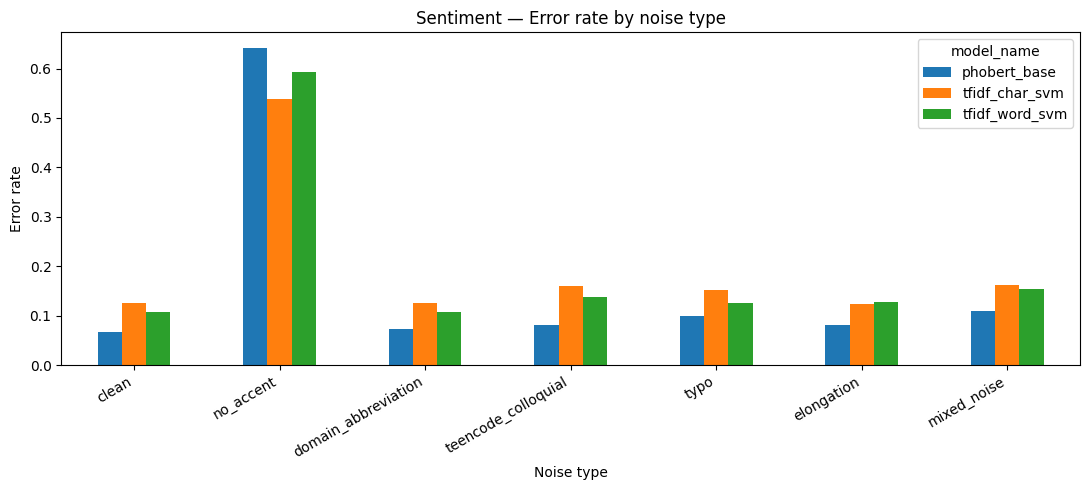

Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\figures\07_error_rate_by_noise_type_sentiment.png


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_4400\3046528254.py:26: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  fig_df


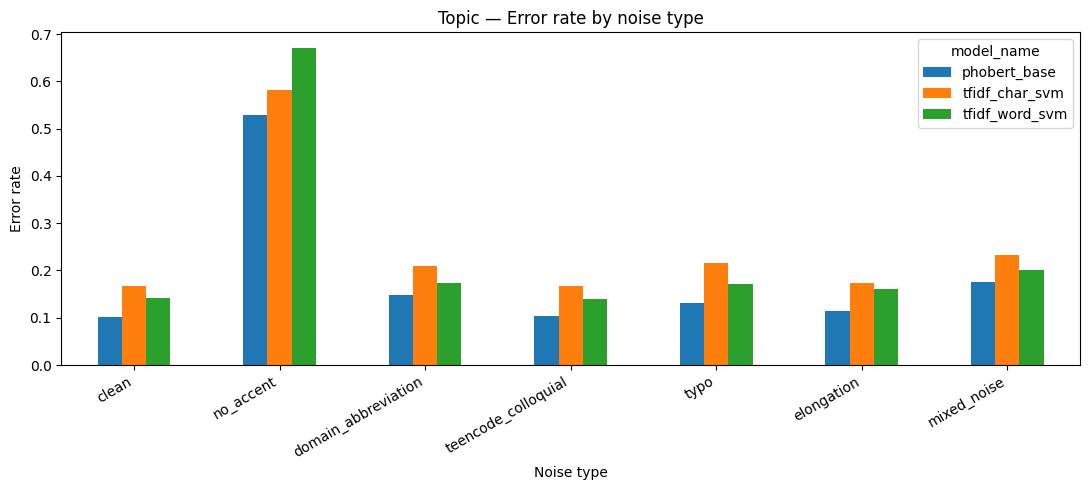

Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\figures\07_error_rate_by_noise_type_topic.png


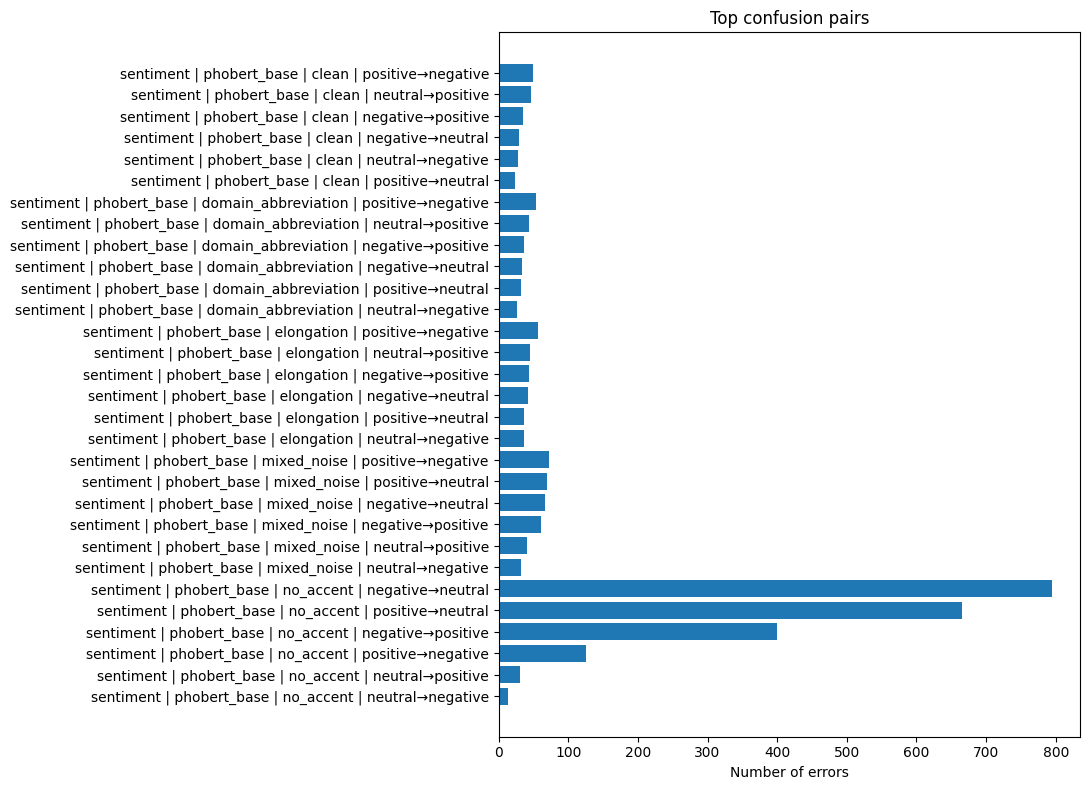

Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\figures\07_top_confusion_pairs.png


In [11]:
primary_scope = analysis_cfg.get("primary_scope", "full")

for task in analysis_cfg.get("tasks", ["sentiment", "topic"]):
    fig_df = error_summary[
        (error_summary["task"] == task)
        & (error_summary["evaluation_scope"] == primary_scope)
        & (error_summary["model_name"] != "majority_class")
    ].copy()

    if fig_df.empty:
        continue

    noise_order = [
        "clean",
        "no_accent",
        "domain_abbreviation",
        "teencode_colloquial",
        "typo",
        "elongation",
        "mixed_noise",
    ]
    available_order = [noise for noise in noise_order if noise in set(fig_df["noise_type"])]
    fig_df["noise_type"] = pd.Categorical(fig_df["noise_type"], categories=available_order, ordered=True)

    pivot = (
        fig_df
        .pivot_table(index="noise_type", columns="model_name", values="error_rate", aggfunc="mean")
        .sort_index()
    )

    ax = pivot.plot(kind="bar", figsize=(11, 5))
    ax.set_title(f"{task.capitalize()} — Error rate by noise type")
    ax.set_xlabel("Noise type")
    ax.set_ylabel("Error rate")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()

    fig_path = FIGURES_DIR / f"07_error_rate_by_noise_type_{task}.png"
    plt.savefig(fig_path, dpi=150)
    plt.show()
    print("Saved:", fig_path)

top_pairs = (
    confusion_pairs[
        (confusion_pairs["evaluation_scope"] == primary_scope)
        & (confusion_pairs["model_name"] != "majority_class")
    ]
    .copy()
    .head(int(analysis_cfg.get("top_confusion_pairs", 30)))
)

if not top_pairs.empty:
    top_pairs["pair"] = (
        top_pairs["task"] + " | "
        + top_pairs["model_name"] + " | "
        + top_pairs["noise_type"] + " | "
        + top_pairs["true_label"] + "→"
        + top_pairs["pred_label"]
    )

    plt.figure(figsize=(11, 8))
    plt.barh(top_pairs["pair"][::-1], top_pairs["num_errors"][::-1])
    plt.title("Top confusion pairs")
    plt.xlabel("Number of errors")
    plt.tight_layout()

    fig_path = FIGURES_DIR / "07_top_confusion_pairs.png"
    plt.savefig(fig_path, dpi=150)
    plt.show()
    print("Saved:", fig_path)
else:
    print("No confusion pairs to plot.")


## 11. Generate Stage 7 report

In [12]:
def dataframe_to_markdown(df: pd.DataFrame) -> str:
    if df.empty:
        return "_Empty table_"

    safe_df = df.copy()
    for col in safe_df.columns:
        if pd.api.types.is_float_dtype(safe_df[col]):
            safe_df[col] = safe_df[col].round(4)
        safe_df[col] = safe_df[col].astype(str)

    headers = safe_df.columns.tolist()
    lines = []
    lines.append("| " + " | ".join(headers) + " |")
    lines.append("| " + " | ".join(["---"] * len(headers)) + " |")

    for _, row in safe_df.iterrows():
        lines.append("| " + " | ".join(row[col] for col in headers) + " |")

    return "\n".join(lines)

report_lines = []
report_lines.append("# Error Analysis Report\n")
report_lines.append(f"- Created at: `{datetime.now().isoformat(timespec='seconds')}`")
report_lines.append("- Stage: `07_error_analysis`")
report_lines.append("- This stage analyzes predictions generated in Stage 6.")
report_lines.append("- No model is trained or evaluated again in Stage 7.\n")

report_lines.append("## Inputs\n")
report_lines.append(f"- Baseline predictions: `{BASELINE_PREDICTIONS_PATH}`")
report_lines.append(f"- PhoBERT predictions: `{PHOBERT_PREDICTIONS_LIGHT_PATH}`")
report_lines.append(f"- Tokenization analysis: `{TOKENIZATION_ANALYSIS_PATH}`\n")

report_lines.append("## Error-rate summary\n")
display_cols = [
    "task", "model_type", "model_name", "noise_type", "evaluation_scope",
    "num_samples", "num_errors", "error_rate",
]
summary_display = (
    error_summary[
        (error_summary["evaluation_scope"] == primary_scope)
        & (error_summary["model_name"] != "majority_class")
    ][display_cols]
    .sort_values(["task", "model_name", "noise_type"])
)
report_lines.append(dataframe_to_markdown(summary_display.head(100)))
report_lines.append("\n")

report_lines.append("## Top confusion pairs\n")
confusion_display = confusion_pairs[
    (confusion_pairs["evaluation_scope"] == primary_scope)
    & (confusion_pairs["model_name"] != "majority_class")
].head(int(analysis_cfg.get("top_confusion_pairs", 30)))
report_lines.append(dataframe_to_markdown(confusion_display))
report_lines.append("\n")

report_lines.append("## Minority and difficult classes\n")
report_lines.append("- Sentiment focus: `neutral`.")
report_lines.append("- Topic focus: `facility`, `others`.")
report_lines.append("- Detailed examples are saved in `07_minority_class_error_samples.csv`.\n")

report_lines.append("## No-accent errors\n")
report_lines.append("- No-accent was the strongest noise type in Stage 6.")
report_lines.append("- Separate tables are exported: `07_no_accent_error_samples.csv` and `07_no_accent_confusion_summary.csv`.\n")

report_lines.append("## Tokenization-related errors\n")
if token_error_summary.empty:
    report_lines.append("- Tokenization-error correlation is unavailable because tokenization features were not joined.\n")
else:
    report_lines.append("- Error rates are summarized by subword inflation bins.")
    report_lines.append("- High-tokenization-shift error examples are exported for qualitative review.\n")

report_lines.append("## Limitations\n")
report_lines.append("- Error samples are selected automatically and still need human interpretation.")
report_lines.append("- Noisy data is rule-generated and not fully human-validated.")
report_lines.append("- Majority-class baseline is excluded from qualitative samples because it ignores input text.")
report_lines.append("- Stage 7 explains observed errors; it does not introduce a new model or normalization method.\n")

report_path = NOTES_DIR / "07_error_analysis_report.md"
report_path.write_text("\n".join(report_lines), encoding="utf-8")

print("Saved:", report_path)


Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\notes\07_error_analysis_report.md


## 12. Final Stage 7 output check

In [13]:
expected_files = [
    TABLES_DIR / "07_predictions_with_text_and_tokenization.csv",
    TABLES_DIR / "07_error_summary_by_model_noise_task.csv",
    TABLES_DIR / "07_confusion_pairs_summary.csv",
    TABLES_DIR / "07_error_samples_all.csv",
    TABLES_DIR / "07_error_samples_sentiment.csv",
    TABLES_DIR / "07_error_samples_topic.csv",
    TABLES_DIR / "07_minority_class_error_samples.csv",
    TABLES_DIR / "07_minority_class_error_summary.csv",
    TABLES_DIR / "07_no_accent_error_samples.csv",
    TABLES_DIR / "07_no_accent_confusion_summary.csv",
    TABLES_DIR / "07_tokenization_error_correlation.csv",
    TABLES_DIR / "07_high_tokenization_shift_error_samples.csv",
    FIGURES_DIR / "07_error_rate_by_noise_type_sentiment.png",
    FIGURES_DIR / "07_error_rate_by_noise_type_topic.png",
    FIGURES_DIR / "07_top_confusion_pairs.png",
    NOTES_DIR / "07_error_analysis_report.md",
]

print("Stage 7 output check:")

all_ok = True
for path in expected_files:
    exists = path.exists()
    all_ok = all_ok and exists
    print("[OK]     " if exists else "[MISSING]", path)

print("\nStage 7 completed:", all_ok)


Stage 7 output check:
[OK]      d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\07_predictions_with_text_and_tokenization.csv
[OK]      d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\07_error_summary_by_model_noise_task.csv
[OK]      d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\07_confusion_pairs_summary.csv
[OK]      d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\07_error_samples_all.csv
[OK]      d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\07_error_samples_sentiment.csv
[OK]      d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\07_error_samples_topic.csv
[OK]      d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\07_minority_class_error_samples.csv
[OK]      d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\07_minority_class_error_summary.csv
[OK]      d:\project-ml-engineering\nlp-phobert-student-feedback\

## What to send for review

Gửi các file sau:

```text
reports/tables/07_error_summary_by_model_noise_task.csv
reports/tables/07_confusion_pairs_summary.csv
reports/tables/07_minority_class_error_summary.csv
reports/tables/07_no_accent_confusion_summary.csv
reports/tables/07_tokenization_error_correlation.csv
reports/notes/07_error_analysis_report.md
```

Không gửi file lớn `07_predictions_with_text_and_tokenization.csv` nếu không được yêu cầu.
